In [ ]:
!pip install yfinance

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf

In [6]:
# Load data
df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')

 # Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print(f'Data downloaded successfully!')

print(f'   Date range: {df.index.min().date()} → {df.index.max().date()}')

/tmp/ipykernel_18595/3183506997.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!
   Date range: 2020-01-02 → 2023-12-29


In [7]:
df.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928078,72.533118,71.708718,72.277601,108872000
2020-01-08,73.085129,73.386446,71.631574,71.631574,132079200
2020-01-09,74.637489,74.830329,73.810677,74.061367,170108400
2020-01-10,74.806236,75.370309,74.304848,74.871326,140644800
2020-01-13,76.404434,76.430954,75.003912,75.122033,121532000
2020-01-14,75.372711,76.551468,75.249779,76.341752,161954400


In [8]:
df.shape


(1006, 5)

In [9]:
df.columns.tolist()

['Close', 'High', 'Low', 'Open', 'Volume']

In [10]:
df.isnull().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1006 non-null   float64
 1   High    1006 non-null   float64
 2   Low     1006 non-null   float64
 3   Open    1006 non-null   float64
 4   Volume  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


In [12]:
df.describe()

Price,Close,High,Low,Open,Volume
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.957992,139.439049,136.328682,137.827952,9.895373e+07
std,33.357829,33.477922,33.218686,33.351564,5.439610e+07
min,54.213600,55.211516,51.372081,55.110034,2.404830e+07
25%,120.397030,121.638017,118.864124,120.502555,6.407675e+07
50%,142.816345,144.390239,141.154868,142.666132,8.467540e+07
75%,163.195049,165.471087,161.941426,163.462842,1.155069e+08
max,196.073074,197.567543,194.974489,195.984003,4.265100e+08


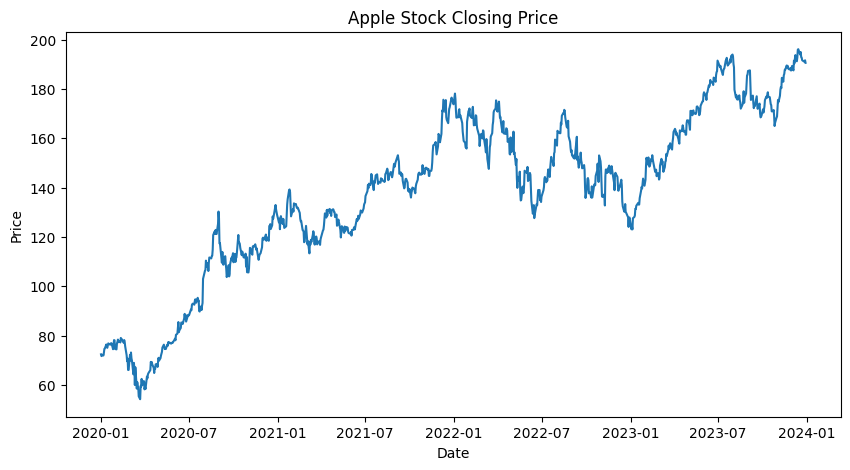

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

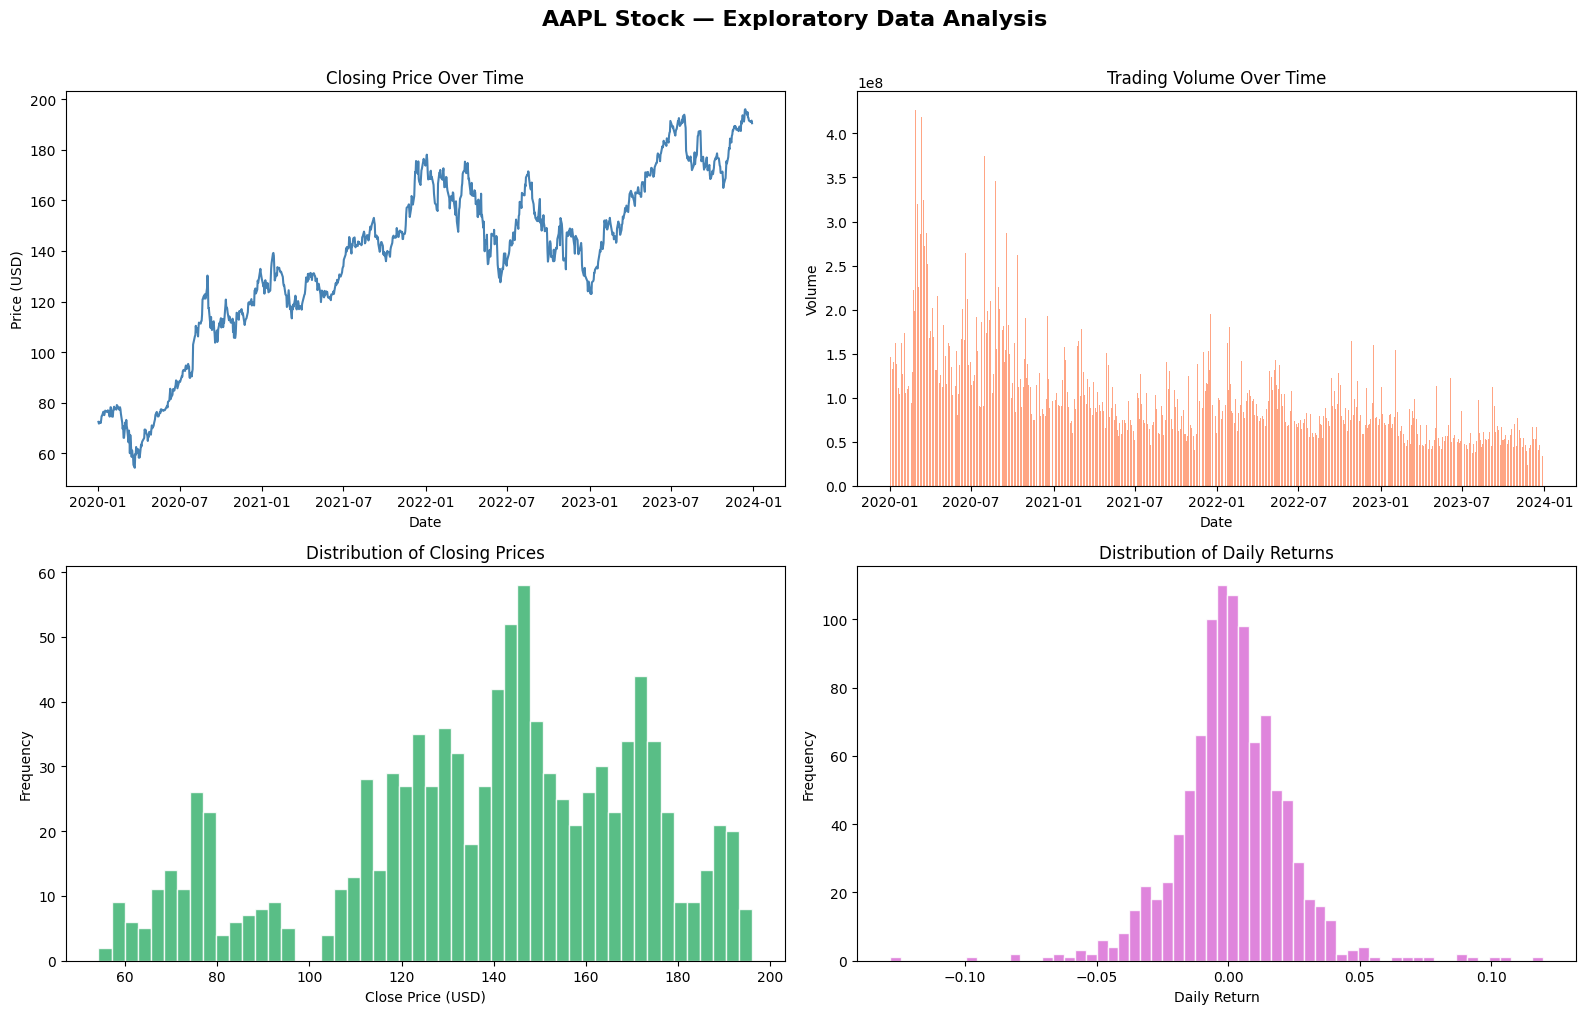

EDA plots saved.


In [14]:

# Plot 1: Closing Price Over Time

TICKER = 'AAPL'
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{TICKER} Stock — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# Closing price trend
axes[0, 0].plot(df.index, df['Close'], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Closing Price Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (USD)')

# Trading volume
axes[0, 1].bar(df.index, df['Volume'], color='coral', alpha=0.7, width=1)
axes[0, 1].set_title('Trading Volume Over Time')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Volume')

# Distribution of daily closing price
axes[1, 0].hist(df['Close'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Distribution of Closing Prices')
axes[1, 0].set_xlabel('Close Price (USD)')
axes[1, 0].set_ylabel('Frequency')

# Daily returns
daily_returns = df['Close'].pct_change().dropna()
axes[1, 1].hist(daily_returns, bins=60, color='orchid', edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Distribution of Daily Returns')
axes[1, 1].set_xlabel('Daily Return')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

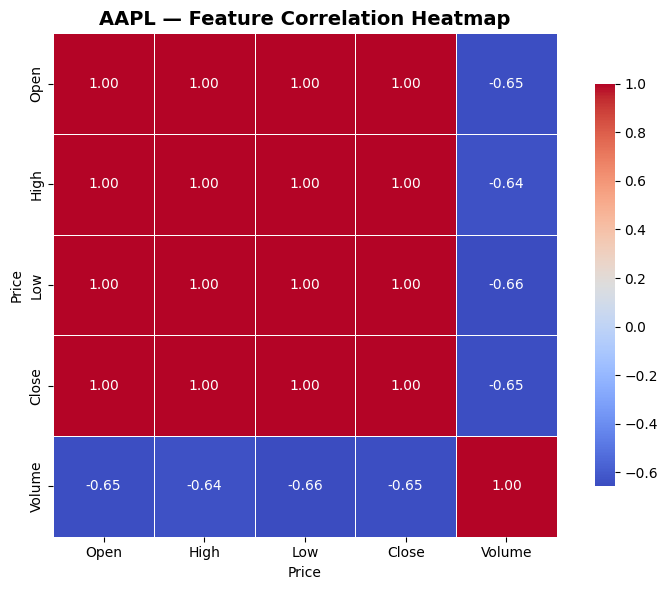

Correlation heatmap saved.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap between OHLCV features

plt.figure(figsize=(8, 6))
corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title(f'{TICKER} — Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Correlation heatmap saved.')

In [16]:
 # Feature Engineering

data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Lag features — previous day's OHLCV
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    data[f'{col}_lag1'] = data[col].shift(1)

# Rolling window statistics (5-day and 10-day)
data['Close_MA5']  = data['Close'].rolling(window=5).mean()
data['Close_MA10'] = data['Close'].rolling(window=10).mean()
data['Close_STD5'] = data['Close'].rolling(window=5).std()

# Daily return
data['Daily_Return'] = data['Close'].pct_change()

# High-Low range
data['HL_Range'] = data['High'] - data['Low']

# Drop NaN rows created by lag/rolling
data.dropna(inplace=True)

print(f'Features engineered. Dataset shape: {data.shape}')
print('\n Feature columns:')
print(data.columns.tolist())

Features engineered. Dataset shape: (997, 15)

 Feature columns:
['Open', 'High', 'Low', 'Close', 'Volume', 'Open_lag1', 'High_lag1', 'Low_lag1', 'Close_lag1', 'Volume_lag1', 'Close_MA5', 'Close_MA10', 'Close_STD5', 'Daily_Return', 'HL_Range']


In [17]:
# Define features (X) and target (y)
# Target: Next day's Close price


# Features: everything except today's Close (we're predicting it)
feature_cols = [
    'Open', 'High', 'Low', 'Volume',
    'Open_lag1', 'High_lag1', 'Low_lag1', 'Close_lag1', 'Volume_lag1',
    'Close_MA5', 'Close_MA10', 'Close_STD5',
    'Daily_Return', 'HL_Range'
]

X = data[feature_cols]
y = data['Close']   # Predict today's Close

print(f' X shape: {X.shape}')
print(f' y shape: {y.shape}')

 X shape: (997, 14)
 y shape: (997,)


In [19]:

# Split data — 80% train, 20% test
# shuffle=False to preserve time order

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, shuffle=False
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')


# Feature Scaling (StandardScaler)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(' Features scaled using StandardScaler.')

Training samples : 797
Testing  samples : 200
 Features scaled using StandardScaler.


In [20]:
  # Model 1: Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print('Linear Regression trained.')

Linear Regression trained.


In [21]:
# Model 2: Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

print(' Random Forest trained.')

 Random Forest trained.


In [22]:
# Evaluation function

def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{'─'*40}')
    print(f'  Model : {name}')
    print(f'  MAE   : ${mae:.4f}')
    print(f'  RMSE  : ${rmse:.4f}')
    print(f'  R²    : {r2:.6f}')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

print(' Model Evaluation Results:\n')
lr_scores = evaluate_model('Linear Regression', y_test, lr_preds)
rf_scores = evaluate_model('Random Forest',     y_test, rf_preds)
print('─'*40)

 Model Evaluation Results:

────────────────────────────────────────
  Model : Linear Regression
  MAE   : $0.4125
  RMSE  : $0.5169
  R²    : 0.997668
────────────────────────────────────────
  Model : Random Forest
  MAE   : $5.8840
  RMSE  : $8.8091
  R²    : 0.322755
────────────────────────────────────────


In [23]:

# Comparison table

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE ($)':  [round(lr_scores['MAE'],  4), round(rf_scores['MAE'],  4)],
    'RMSE ($)': [round(lr_scores['RMSE'], 4), round(rf_scores['RMSE'], 4)],
    'R² Score': [round(lr_scores['R2'],   6), round(rf_scores['R2'],   6)]
})

print(' Model Comparison Summary:')
display(results_df.style.highlight_min(subset=['MAE ($)', 'RMSE ($)'], color='lightgreen')
                        .highlight_max(subset=['R² Score'], color='lightgreen')
                        .set_caption('Green = Better performance'))

 Model Comparison Summary:


,Model,MAE ($),RMSE ($),R² Score
0,Linear Regression,0.412500,0.516900,0.997668
1,Random Forest,5.884000,8.809100,0.322755


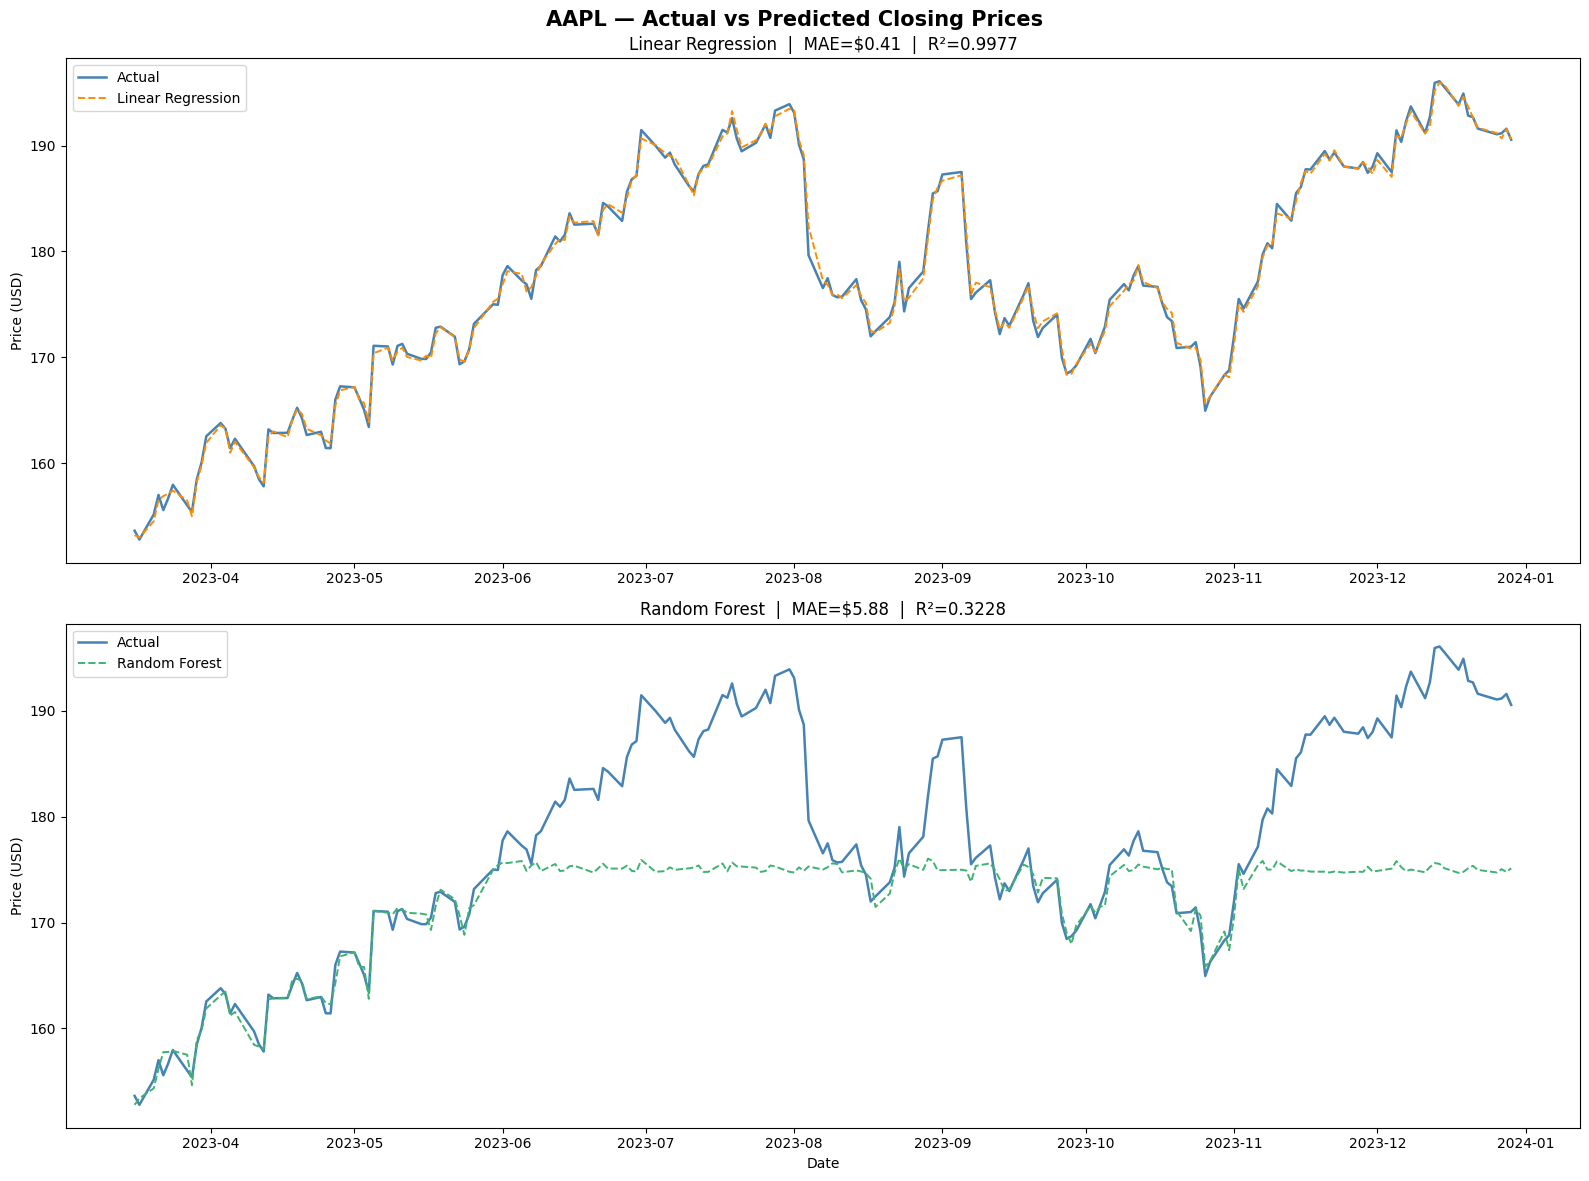

 Actual vs Predicted plot saved.


In [27]:

# Plot: Actual vs Predicted — Both Models

test_dates = data.index[-len(y_test):]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle(f'{TICKER} — Actual vs Predicted Closing Prices', fontsize=15, fontweight='bold')

# --- Linear Regression ---
axes[0].plot(test_dates, y_test.values, label='Actual',           color='steelblue',    linewidth=1.8)
axes[0].plot(test_dates, lr_preds,      label='Linear Regression',color='darkorange',   linewidth=1.4, linestyle='--')
axes[0].set_title(f'Linear Regression  |  MAE=${lr_scores["MAE"]:.2f}  |  R²={lr_scores["R2"]:.4f}')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# --- Random Forest ---
axes[1].plot(test_dates, y_test.values, label='Actual',        color='steelblue',  linewidth=1.8)
axes[1].plot(test_dates, rf_preds,      label='Random Forest', color='mediumseagreen', linewidth=1.4, linestyle='--')
axes[1].set_title(f'Random Forest  |  MAE=${rf_scores["MAE"]:.2f}  |  R²={rf_scores["R2"]:.4f}')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Actual vs Predicted plot saved.')

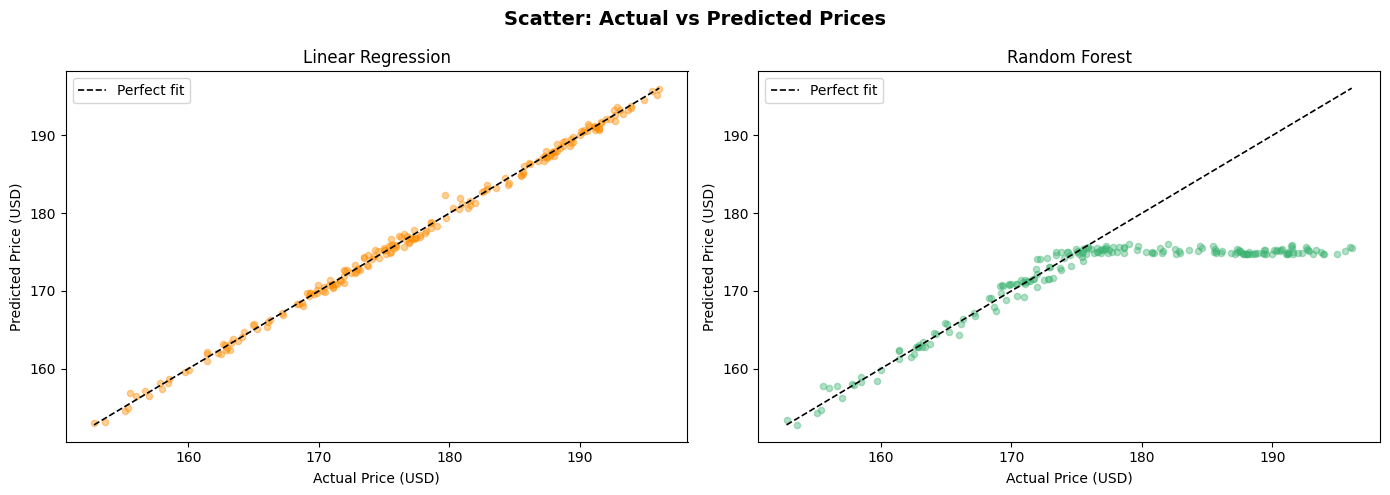

In [28]:
 # Scatter plots: Actual vs Predicted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter: Actual vs Predicted Prices', fontsize=14, fontweight='bold')

for ax, preds, name, color in zip(
    axes,
    [lr_preds, rf_preds],
    ['Linear Regression', 'Random Forest'],
    ['darkorange', 'mediumseagreen']
):
    ax.scatter(y_test, preds, alpha=0.4, color=color, s=20)
    min_v = min(y_test.min(), preds.min())
    max_v = max(y_test.max(), preds.max())
    ax.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1.2, label='Perfect fit')
    ax.set_title(name)
    ax.set_xlabel('Actual Price (USD)')
    ax.set_ylabel('Predicted Price (USD)')
    ax.legend()

plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

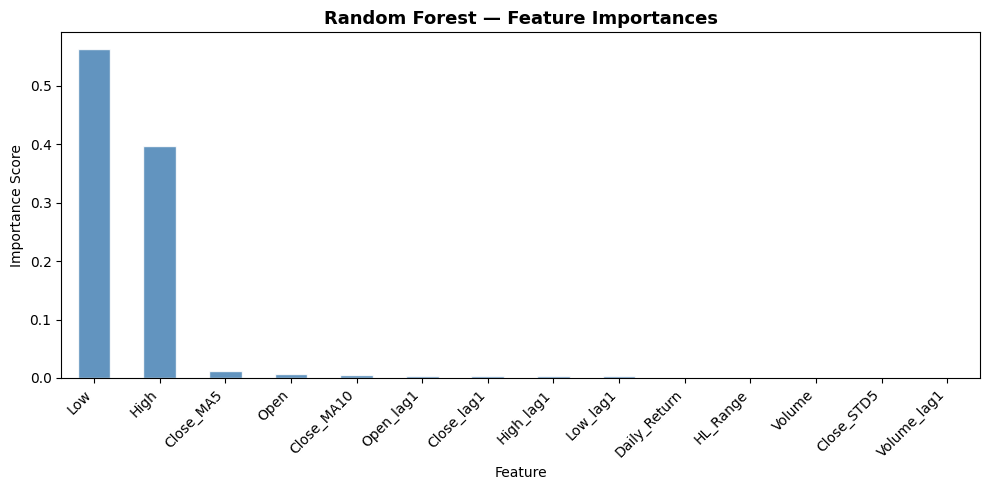


 Top 5 Most Important Features:
Low           0.563487
High          0.396823
Close_MA5     0.011439
Open          0.006844
Close_MA10    0.005307
dtype: float64


In [29]:

# Feature Importance (Random Forest)

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Top 5 Most Important Features:')
print(importances.head())